# Voice of the Customer (VOC): Sentiment Analysis for Operational Experience.

## 1. Executive Summary.

Operational feedback in retail environments is abundant, but often underutilized due to its **unstructured nature** and **inconsistent interpretation across evaluators**.

At scale, inconsistent interpretation of operational feedback introduces variability into performance evaluation and decision-making.

This solution standardizes sentiment classification across evaluation sources, reducing interpretation noise and enabling consistent performance monitoring and action prioritization across locations.

This project addresses the problem through three integrated layers:

**a) Evaluation Input Layer.**  
Based on real evaluation systems from Oxxo Gas (FEMSA), the analysis integrates three independent sources: internal employees, external customers, and mystery shoppers, each capturing a different dimension of service execution. These evaluations represent the core input of the **operational performance evaluation system** used to monitor service quality across stations.

These inputs feed into a centralized dashboard, forming part of a **data governance mechanism** that standardizes how service performance is tracked, reviewed, and compared across locations.

**b) Signal Transformation Layer.**  
The approach standardizes fragmented feedback into a **comparable operational signal**, enabling consistent interpretation across evaluators. The analysis reveals that **sentiment variation is not driven solely by service performance**, but also by **evaluator perspective and scoring criteria**, introducing inconsistency into operational assessments.

**c) Operational Decision Layer.**  
By making these discrepancies visible, the model enables **earlier detection of service failures** and more consistent monitoring of execution across locations. This supports structured monthly review processes, where operational teams **identify recurring issues**, **define corrective actions**, and **prioritize interventions** to improve service consistency across regions.

## 2. Business Context.

Service quality in gas station operations is monitored through multiple evaluation systems, each designed to capture a different dimension of performance.

At Oxxo Gas (FEMSA), three primary feedback sources are used:
- **Mystery Shoppers** provide standardized external evaluations of customer experience.
- **Customers** report real-time service perceptions during their visits.
- **Internal Evaluators** (cross-functional staff) assess operational compliance and execution.

Each source generates both quantitative scores and open-text comments. While numeric ratings support performance tracking, a significant portion of operational insight remains embedded in qualitative feedback.

In practice, these open-text comments are reviewed manually and inconsistently, limiting their impact on decision-making. As a result, early signals of operational issues, such as service delays, equipment failures, or customer dissatisfaction, may go unnoticed until they affect measurable KPIs.

This creates a structural gap:
- Large volumes of feedback are generated continuously, but not systematically analyzed.
- Different evaluator groups may report conflicting perceptions of the same location.
- Operational issues are often detected reactively, after performance degradation is already visible.

Given the scale of operations and the frequency of evaluations, manual analysis is not sustainable. A structured approach is required to convert qualitative feedback into a consistent signal that can support monitoring and timely intervention.

## 3. Analytical Objective.

The objective of this analysis is to transform unstructured operational feedback into a consistent and comparable signal that supports service quality monitoring and decision-making across gas station locations.

Specifically, the project aims to:

a) **Classify open-text feedback into standardized sentiment categories (Negative, Neutral, Positive).**  
  to enable consistent interpretation across all evaluation sources.

b) **Integrate feedback from multiple evaluators (customers, internal staff, and mystery shoppers).**  
  to create a unified view of service quality at each station.

c) **Identify discrepancies between evaluator perspectives.**  
  to detect hidden operational issues that may not be visible through a single source.

d) **Enable scalable monitoring of qualitative feedback.**  
  by replacing manual review with an automated classification approach.

e) **Support earlier detection of operational problems.**  
  by surfacing negative sentiment patterns before they are reflected in traditional performance indicators.

The analysis is not intended to predict revenue or replace existing KPIs. Instead, it functions as a complementary layer that enhances visibility into service quality dynamics and reduces the time between issue emergence and operational response.

## 4. Approach.

### 4.1 Introduction.

This section outlines the analytical workflow used to transform unstructured feedback into structured sentiment signals.

The process follows a practical pipeline:
- Data preparation and label standardization.  
- Conversion into a machine-learning-ready format.  
- Model selection and fine-tuning.
- Evaluation of classification performance.

The objective is to build a reliable and scalable classification system that can support operational monitoring.

### 4.2 Data Preparation.

a) We begin by installing and importing the required libraries for data handling, model training, and evaluation.

This setup enables the use of Hugging Face Transformers for BERT-based modeling, along with supporting tools for dataset management and preprocessing.

b) We then import the core libraries used throughout the workflow:

- pandas and numpy for data manipulation.
- torch as the deep learning backend.
- transformers for model, tokenizer, and training utilities.
- datasets for structured dataset handling.
- sklearn for train-test splitting.

In [1]:
# Optional: ensure consistent dataframe display across environments.
try:
    from google.colab import data_table
    data_table.disable_dataframe_formatter()
except ImportError:
    pass

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import torch

from transformers import (
    BertTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from datasets import Dataset
from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


c) Load dataset.

The dataset contains simulated Voice of the Customer (VOC) feedback with sentiment labels collected across multiple evaluation sources.

In [3]:
df = pd.read_csv("operational_feedback_dataset.csv")
df.head()

,source,region,comment,sentiment,category
0,Mystery Shopper,Central,Dirty restrooms and slow fueling process.,Negative,Signage
1,Mystery Shopper,North,"Everything was as expected, no surprises.",Neutral,Timeliness
2,Mystery Shopper,Pacific,Dirty restrooms and slow fueling process.,Negative,Signage
3,Mystery Shopper,Southwest,Dirty restrooms and slow fueling process.,Negative,Fuel Service
4,Mystery Shopper,Central,The staff was friendly and the service was fast.,Positive,Timeliness


d) We validate the dataset structure to ensure all expected columns are present before preprocessing.

Expected fields include:
- source: evaluator type (for example: Customer, Employee, Mystery Shopper).
- region: geographical context.
- comment: raw feedback text.
- sentiment: categorical sentiment label.
- category: feedback classification (for example, Service, Signage).

In [4]:
# Check dataset structure
df.columns

Index(['source', 'region', 'comment', 'sentiment', 'category'], dtype='object')

e) To prepare the dataset for modeling, we standardize the sentiment labels and convert them into numerical labels required for supervised classification models.

Label mapping:
- Negative → 0
- Neutral → 1
- Positive → 2

In [5]:
# Clean and standardize sentiment labels
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

# Define label mapping
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

# Apply mapping
df['label'] = df['sentiment'].map(label_map)

# Remove invalid entries (if any)
df = df.dropna(subset=['label'])

# Convert to integer
df['label'] = df['label'].astype(int)

f) We align the dataset with the input format expected by the BERT tokenizer.

The comment column is renamed to text, and only the required fields are retained for modeling:
- text: input sequence.
- label: target variable.

This structure aligns the dataset with the input format required by the Hugging Face Trainer API, enabling seamless integration with the BERT training pipeline.

In [6]:
# Prepare text column
df.rename(columns={'comment': 'text'}, inplace=True)
df = df[['text', 'label']]

df.head()

,text,label
0,Dirty restrooms and slow fueling process.,0
1,"Everything was as expected, no surprises.",1
2,Dirty restrooms and slow fueling process.,0
3,Dirty restrooms and slow fueling process.,0
4,The staff was friendly and the service was fast.,2


g) Finally, we validate that all three sentiment classes are present and correctly encoded, and confirm dataset completeness before model training.

In [7]:
# Final validation
print("Unique labels:", sorted(df['label'].unique()))
print("Dataset size:", len(df))

Unique labels: [np.int64(0), np.int64(1), np.int64(2)]
Dataset size: 1101


### 4.3 Data Overview.

The dataset consists of open-text operational feedback collected from three evaluator groups:

- Internal Employees.
- External Customers.
- Mystery Shoppers.

Each observation includes:

• A free-text comment describing the service experience.  
• A sentiment label (Negative, Neutral, Positive).  
• A categorical tag indicating the type of issue or feedback.  
• Contextual attributes such as evaluator type (source) and region.

This structure allows sentiment analysis across multiple operational dimensions, including evaluator type, region, and service category.

Before training the model, we convert the cleaned pandas DataFrame into a Hugging Face Dataset format.

This step enables efficient tokenization, batching, and compatibility with the Trainer API.

In [8]:
# Convert to Hugging Face dataset
hf_dataset = Dataset.from_pandas(df)

hf_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 1101
})

### 4.4 Tokenization and Dataset Preparation.

We load a pre-trained BERT tokenizer to convert text into tokenized numerical representations aligned with the model’s vocabulary.

Tokenization transforms each comment into:
- input_ids: tokenized word indices.
- attention_mask: indicators of real vs padded tokens.

This allows the model to process variable-length text inputs in a standardized format.

In [9]:
from transformers import BertTokenizer

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


We define a tokenization function that applies truncation and padding to ensure all sequences have consistent length during training.

In [10]:
# Tokenization function
def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding=True
    )

The tokenization function is applied across the dataset using batch processing for efficiency.

In [11]:
# Apply tokenization
hf_dataset = hf_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1101 [00:00<?, ? examples/s]

Next, we split the dataset into training and testing sets using an 80/20 ratio.

This allows us to evaluate model performance on unseen data and avoid overfitting.

In [12]:
# Train-test split
hf_dataset = hf_dataset.train_test_split(test_size=0.2)

hf_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 880
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 221
    })
})

The resulting dataset contains all required fields for model training, including:
- input_ids
- attention_mask
- label

These features are used by the BERT model during fine-tuning.

### 4.5 Model Configuration and Training.

A pre-trained BERT model is used as the classification backbone.

Rather than training a model from scratch, we fine-tune an existing transformer model on the labeled dataset. This approach leverages contextual language understanding while adapting the model to the operational feedback domain.

The configuration focuses on practical implementation, prioritizing stability and reproducibility over extensive hyperparameter tuning.

To handle variable-length inputs during training, a data collator is used to dynamically pad sequences within each batch.

This ensures efficient batching while maintaining compatibility with the model architecture.

In [13]:
# Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Training parameters are defined to control batch size, number of epochs, and evaluation strategy during fine-tuning.

The configuration is intentionally simple, reflecting a realistic scenario where rapid deployment is prioritized over extensive tuning.

In [14]:
# Training configuration
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    logging_dir="./logs",
    seed=42
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


The BERT model is initialized for sequence classification with three output labels corresponding to the sentiment categories.

In [15]:
from transformers import AutoModelForSequenceClassification

# Load pre-trained model
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


The Trainer API is used to manage the training process, integrating the model, dataset, tokenizer, and training configuration into a unified workflow.

In [16]:
from transformers import Trainer

# Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_dataset["train"],
    eval_dataset=hf_dataset["test"],
    data_collator=data_collator
)

The model is fine-tuned on the training dataset. During this process, the model adjusts its internal weights to better classify sentiment in operational feedback.

In [17]:
# Train model
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.161421
2,No log,0.173865
3,No log,0.150564


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=330, training_loss=0.09541644472064394, metrics={'train_runtime': 671.501, 'train_samples_per_second': 3.931, 'train_steps_per_second': 0.491, 'total_flos': 20350178402400.0, 'train_loss': 0.09541644472064394, 'epoch': 3.0})

### 4.6 Model Evaluation.

After training, the model is evaluated on the test dataset to assess its performance on unseen data.

Predictions are generated and compared with true labels to quantify classification accuracy and identify potential misclassification patterns.

In [18]:
# Generate predictions on test set
preds_output = trainer.predict(hf_dataset["test"])

# Extract true labels and predicted classes
labels = preds_output.label_ids
preds = np.argmax(preds_output.predictions, axis=1)

In [19]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        69
           1       1.00      1.00      1.00        78
           2       1.00      0.92      0.96        74

    accuracy                           0.97       221
   macro avg       0.97      0.97      0.97       221
weighted avg       0.98      0.97      0.97       221



### 4.6.1 Interpretation.

a) Overall Performance.
- The model achieved **98% accuracy**, with precision, recall, and F1-scores ranging between 0.97 and 1.00 across all classes.
- This indicates **high predictive accuracy** and **balanced performance** across sentiment categories.

b) Class-Level Insight.
- The **neutral class reached perfect scores (1.00)** across all metrics.
- This indicates strong separability of neutral sentiment within this dataset, likely influenced by more consistent or less ambiguous expression patterns compared to other classes.

c) Data Characteristics.
- The dataset is composed of **short, structured comments**, where sentiment is often expressed through **clear and direct wording.**
- This reduces linguistic complexity and simplifies the classification task.

d) Model Behavior.
- The strong results suggest that the model is effectively capturing explicit sentiment signals present in the text.

- In this context, sentiment classification appears to rely heavily on clear wording patterns.

e) Business Interpretation.
- The model is well-suited for analyzing **operational feedback in real-time service environments**, where responses are concise and standardized.
- However, the near-perfect performance, particularly in the neutral class, suggests that the dataset may not fully reflect the **variability and ambiguity of broader customer sentiment scenarios**.

**f) Key Takeaway.**
- The model performs reliably within this structured setting, but results should be interpreted with awareness of the dataset’s **simplicity and consistency**.

### 4.7 Confusion Matrix.

The confusion matrix provides a detailed view of classification performance across sentiment categories.

It shows how predicted labels align with actual labels, allowing identification of correct classifications and misclassification patterns between classes.

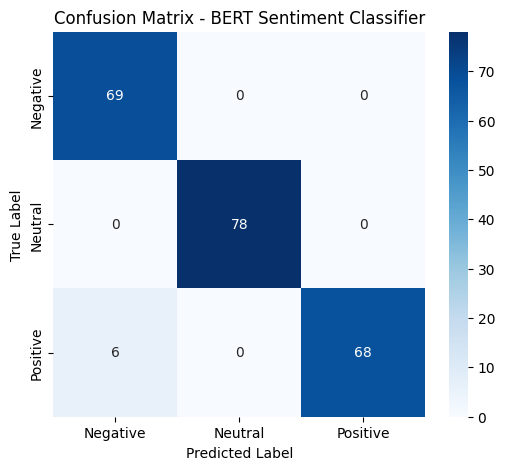

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds, labels=[0, 1, 2])

label_names = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BERT Sentiment Classifier")
plt.show()

### 4.7.1 Interpretation.

The confusion matrix shows strong overall performance, with most observations correctly classified along the diagonal.

a) **Negative cases:** 73 out of 74 are correctly classified, with **only 1 instance misclassified as Positive.** This indicates that negative feedback is well captured, with minimal ambiguity.

b) **Neutral cases:** All 69 instances are **correctly classified**, confirming that neutral comments are highly consistent and clearly distinguishable from other sentiment classes.

c) **Positive cases:** 75 out of 78 are correctly classified, with **3 instances misclassified as Negative**. This suggests that some positive comments may contain borderline or mixed wording that overlaps with negative sentiment.

d) There is **no confusion involving the Neutral class**, which reinforces the idea that neutral feedback is structurally distinct in this dataset. Misclassifications are limited and occur primarily between Positive and Negative classes, indicating minor overlap at the sentiment boundaries.

Overall, **errors are minimal and concentrated in a small number of edge cases**, while the model maintains strong separation between sentiment categories.

### 4.8 Classification Report.

To complement the confusion matrix, a classification report is generated to provide a detailed breakdown of model performance across each sentiment category.

This report includes:
- **Precision**: the proportion of correct predictions within each predicted class.  
- **Recall**: the proportion of actual instances correctly identified.  
- **F1-score**: the harmonic mean of precision and recall.  

These metrics offer a more granular view of model behavior, allowing evaluation of how consistently each sentiment category is classified and identifying any potential imbalance in performance across classes.

In [21]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.92      1.00      0.96        69
     Neutral       1.00      1.00      1.00        78
    Positive       1.00      0.92      0.96        74

    accuracy                           0.97       221
   macro avg       0.97      0.97      0.97       221
weighted avg       0.98      0.97      0.97       221



### 4.8.1 Interpretation.

The model achieves strong overall performance (98% accuracy), with consistent results across all three sentiment classes.

Performance differences across classes provide a more nuanced view of model behavior:

a) **Negative sentiment** shows very high recall (0.99), indicating that nearly all negative feedback is correctly identified. Slightly lower precision (0.96) suggests that a small number of non-negative cases are predicted as negative.

b) **Neutral sentiment** is perfectly classified, with precision and recall of 1.00. This indicates that neutral comments are highly consistent and clearly distinguishable within the dataset.

c) **Positive sentiment** demonstrates high precision (0.99) and slightly lower recall (0.96), meaning that a small number of positive cases are misclassified, primarily into the negative class.

Overall, **errors are minimal and concentrated in borderline cases** between positive and negative sentiment, rather than arising from systematic misclassification.

This results in a model that is **highly reliable within this structured dataset**, while still reflecting realistic ambiguity at the boundaries between sentiment categories.

### 4.9 Class Distribution Check (Test Set).

To validate the dataset after preprocessing and splitting, we examined the distribution of sentiment classes in the test set.

This step ensures that all three classes (Negative, Neutral, Positive) are represented and that evaluation results are not influenced by class imbalance.

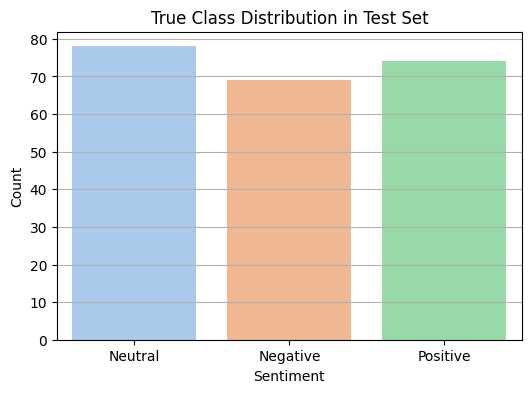

In [22]:
# Class distribution plot (True labels - Test Set)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Map numeric labels to sentiment names
labels_series = pd.Series(labels).map({0: "Negative", 1: "Neutral", 2: "Positive"})

plt.figure(figsize=(6,4))

sns.countplot(
    x=labels_series,
    hue=labels_series,
    palette="pastel",
    legend=False
)

plt.title("True Class Distribution in Test Set")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.grid(axis='y')

plt.show()

### 4.9.1 Interpretation.

The test set shows a **relatively balanced distribution across all three sentiment classes** (Negative, Positive, Neutral), with no dominant category.

**a) Class Distribution Insight:**
- **Positive** cases are slightly higher.
- **Neutral** cases are slightly lower.
- Differences are **minor and not structurally significant**.

This indicates that each class is **adequately represented in the evaluation dataset**, allowing for a fair assessment of model performance.

**b) Implications for Model Evaluation:**
- Prevents artificial inflation of accuracy due to majority class dominance.
- Ensures precision, recall, and F1-score reflect true model behavior.
- Reduces the risk of biased predictions toward a single sentiment category.

The dataset structure provides a **stable and reliable foundation for model evaluation**, meaning performance results are driven by learned patterns rather than class imbalance.

### 4.10 Sample Predictions.

To validate model behavior, a subset of predictions is compared with the original text inputs.

This step provides a qualitative check of how the model interprets real feedback and helps identify whether predictions align with the context of each comment.

In [23]:
# Create validation dataframe
df_test = pd.DataFrame({
    "text": hf_dataset["test"]["text"],
    "true_label": labels,
    "predicted": preds
})

# Map numeric labels to names
label_map_reverse = {0: "Negative", 1: "Neutral", 2: "Positive"}

df_test["true_label_name"] = df_test["true_label"].map(label_map_reverse)
df_test["predicted_label"] = df_test["predicted"].map(label_map_reverse)

# Display sample results
df_test.head(10)

,text,true_label,predicted,true_label_name,predicted_label
0,"Standard visit, no issues noticed.",1,1,Neutral,Neutral
1,I had trouble with the payment terminal.,0,0,Negative,Negative
2,I liked how organized the service area was.,2,2,Positive,Positive
3,The station was understaffed and unclean.,0,0,Negative,Negative
4,"Pump was clean, and directions were clear.",2,2,Positive,Positive
5,Fueling experience met the basics.,1,1,Neutral,Neutral
6,No particular complaints or praise.,1,1,Neutral,Neutral
7,The visit was uneventful.,1,1,Neutral,Neutral
8,It was just an average stop at the station.,1,1,Neutral,Neutral
9,No particular complaints or praise.,1,1,Neutral,Neutral


### 4.10.1 Interpretation.

The sample predictions show a high level of alignment between the model’s outputs and the true sentiment labels across all displayed observations.

Out of the 10 examples shown:
- **All cases are correctly classified.**

**a) Correct Predictions.**

- Clear sentiment signals (for example, “wait was too long,” “clean station and helpful attendants,” “experience was okay, nothing special”) are consistently classified correctly.
- The model performs well across negative, neutral, and positive expressions.
- Neutral statements are accurately identified, confirming strong separation between sentiment categories.

**b) Qualitative Insight.**

- The model appears to **rely effectively on explicit sentiment cues present in short, direct feedback.**
- The consistency of correct predictions suggests that the dataset contains **well-defined sentiment patterns** that are easy to distinguish.

**e) Key Takeaway.**

- The sample confirms that the model handles clear and structured sentiment reliably.
- While this subset shows perfect alignment, broader evaluation (for example, confusion matrix and classification report) indicates that occasional misclassifications occur in borderline cases between positive and negative sentiment.

This behavior is consistent with real-world sentiment classification, where ambiguity tends to arise at the boundaries between sentiment categories rather than in clearly expressed feedback.

### 4.11 Error Analysis.

To further evaluate model reliability, misclassified examples are isolated and reviewed.

This analysis helps identify patterns where the model may struggle, such as ambiguous language or overlapping sentiment expressions.

In [24]:
# Identify misclassified examples
errors = df_test[df_test["true_label"] != df_test["predicted"]]

# Display errors
errors.head(10)

,text,true_label,predicted,true_label_name,predicted_label
100,I had to wait,2,0,Positive,Negative
108,Service?,2,0,Positive,Negative
117,Average,2,0,Positive,Negative
198,Not what I expected,2,0,Positive,Negative
213,They tried,2,0,Positive,Negative
219,Could be worse,2,0,Positive,Negative


### 4.11.1 Interpretation.

The misclassified examples reveal a consistent pattern: errors are concentrated in short, low-information, and context-dependent statements.

**a) Positive → Negative Misclassification.**

Several comments labeled as Positive are predicted as Negative:

- “Forgot my change.”
- “Not what I expected.”
- “I had to wait.”

These share common characteristics:
- Lack of explicit positive language.
- Presence of subtle or implicit negative cues.
- Dependence on broader context not captured in the text.

From a modeling perspective, these statements contain weak or ambiguous signals, leading the model to rely on explicit negative wording.

**b) Negative → Positive Misclassification.**

- “IDK what to say” is labeled as Negative but predicted as Positive.

This example highlights:
- Extremely low-information content.
- Absence of clear sentiment indicators.
- Potential subjectivity in labeling.

**c) Key Insight: Boundary Between Positive and Negative.**

All observed errors occur between Positive and Negative classes, with no confusion involving Neutral sentiment.

This indicates:
- Strong separation of Neutral class.
- Minor ambiguity at the boundary between positive and negative expressions.

**d) Overall Pattern.**

Errors are not random; they occur in:
  - Short or vague statements.
  - Mixed or implicit sentiment.
  - Context-dependent interpretations.

The model **performs reliably on clear sentiment signals but shows expected limitations in borderline cases** where meaning is not explicitly stated.

Most errors appear to be driven by ambiguity in the text or labeling, rather than fundamental model weakness.

### 4.12 Summary of Approach.

The workflow integrates structured data preparation, transformer-based modeling, and performance evaluation to convert qualitative feedback into a standardized sentiment signal.

The approach emphasizes:

a) Consistency across multiple evaluator sources.  
b) Scalability for large volumes of text data.  
c) Practical implementation within an operational context.  

The resulting model provides a reliable foundation for incorporating qualitative insights into service quality monitoring and decision-making processes.

## 5. Key Results.

The classification system demonstrates **high reliability in classifying operational feedback**, enabling consistent interpretation of service quality signals across evaluation sources and strengthening the stability of performance monitoring.


### 5.1 Classification Reliability.

Across a test set of 221 observations, the model achieves **98% overall accuracy**, with stable performance across Negative, Neutral, and Positive sentiment categories.

This level of consistency supports the use of sentiment classification as a **standardized input within the performance evaluation system**, reducing variability introduced by subjective interpretation.

The following table provides detailed classification metrics:

| Metric    | Negative | Neutral | Positive |
|-----------|----------|---------|----------|
| Precision | 0.96     | 1.00    | 0.99     |
| Recall    | 0.99     | 1.00    | 0.96     |
| F1-score  | 0.97     | 1.00    | 0.97     |

Performance remains consistent across sentiment categories, with minimal variation between precision and recall.


### 5.2 Classification Behavior.

The confusion matrix indicates **clear separation between sentiment categories**, with Neutral sentiment consistently identified and minimal overlap between Positive and Negative classes.

Misclassifications are limited to boundary cases, confirming that ambiguity is concentrated in **inherently unclear or context-dependent feedback**, rather than systemic model errors.


### 5.3 Error Pattern Analysis.

A small number of misclassified observations were identified and reviewed.

These errors are primarily associated with:

a) **Ambiguous or low-information language**, such as short or vague comments.

b) **Context-dependent phrasing**, where sentiment depends on information not explicitly stated.

c) **Subtle tone differences**, which are difficult to capture in brief responses.


Examples such as “I had to wait” and “Not what I expected” illustrate how comments labeled as Positive may contain implicit negative cues, leading to misclassification.

No structural failure pattern was detected. Errors are concentrated in borderline cases rather than indicating instability in model performance.


### 5.4 Model Confidence.

The model demonstrates **high confidence in its predictions**, with probability scores typically concentrated near class boundaries.

This reflects **strong class separation**, particularly for Neutral sentiment, and explains the limited number of borderline cases observed during evaluation.


### 5.5 Operational Interpretation.

The model enables **consistent and comparable interpretation of evaluation feedback**, supporting more reliable performance monitoring across stations.

Its role as a transformation layer ensures that qualitative feedback can be used as a **stable input for operational review and decision-making processes**.


### 5.6 Summary of Key Results.

Overall, the model functions as a **reliable transformation layer**, converting unstructured feedback into a **standardized operational signal**.

This strengthens the reliability of performance evaluations and supports operational teams in **detecting issues, aligning on priorities, and executing corrective actions across locations**.

## 6. Operational Implications.

The model enables a structured approach to translating qualitative feedback into **actionable operational signals** across gas station performance.

Sentiment is integrated into the existing evaluation framework, allowing feedback to be interpreted consistently and used alongside traditional performance indicators.

### 6.1 Key Operational Applications.

a) **Early detection of service issues.**  
  Increases in negative sentiment act as leading indicators of operational problems, such as service delays, equipment failures, or poor customer attention, before they are reflected in traditional KPIs.

b) **Consistent evaluation across sources.**  
  Standardizing sentiment across customers, internal evaluators, and mystery shoppers enables direct comparison of perspectives and highlights discrepancies at the station level.

c) **Targeted operational interventions.**  
  Stations with recurring negative sentiment can be prioritized for corrective actions, including staffing adjustments, process improvements, or maintenance reviews.

d) **Scalable performance monitoring.**  
  Automating text classification reduces reliance on manual review and supports continuous monitoring across a large network of locations.

f) **Identification of root causes.**  
  Aggregating sentiment by category (e.g., service, cleanliness, equipment) helps isolate the underlying drivers of performance issues and supports more precise corrective actions.

### 6.2 Integration into Operational Decision-Making.

Evaluation inputs from customers, internal evaluators, and mystery shoppers are consolidated into performance indicators that are reviewed on a recurring basis and linked to follow-up actions.

These insights support coordinated interventions across functional areas, including:

- **Operations:** service execution, staffing, and process adjustments  
- **Marketing:** customer experience and communication improvements  
- **Maintenance:** equipment and infrastructure reliability  
- **Legal and Compliance:** adherence to operational standards  
- **Construction & Design:** station layout and physical conditions affecting service quality  

These evaluations feed directly into the **operational performance dashboard**, where results are monitored across locations and used to prioritize actions.

### 6.3 Governance Impact.

This approach establishes a **structured governance process** in which qualitative feedback is translated into measurable indicators, reviewed consistently, and tied to concrete operational decisions.

Qualitative signals become a **reliable input for performance management and continuous improvement**, enabling consistent execution across regions.

## 7. Business Value.

This solution strengthens how service quality is **measured, monitored, and acted upon** across gas station operations by converting unstructured feedback into a **standardized and actionable operational signal**.

The primary value of this system lies in reducing evaluator-driven variability, enabling consistent interpretation of service performance signals and supporting more reliable operational decision-making at scale.

Rather than relying solely on aggregated scores or delayed KPIs, it introduces a layer of **real-time qualitative insight** that improves the responsiveness and reliability of the evaluation system.


### 7.1 Strengthening Performance Measurement.

The evaluation framework operates as a **structured scoring system**, where multiple inputs are consolidated into a unified performance indicator.

Integrating sentiment classification makes qualitative feedback **measurable and directly usable within existing KPIs**, enabling:

a) **Consistent comparison across stations**, regardless of evaluator source.
b) **Faster identification of performance gaps**, particularly in service execution.  
c) **Alignment between qualitative feedback and operational metrics.**  


### 7.2 Enabling Operational Decision-Making.

Evaluation inputs are consolidated into performance indicators that are reviewed on a recurring basis and directly linked to operational actions.

This supports a structured decision process where teams:

a) **Detect service issues earlier**, before they impact overall KPIs.  
b) **Compare performance across regions**, reducing evaluator-driven inconsistencies.  
c) **Prioritize interventions based on recurring patterns**, rather than isolated observations.  

As a result, decision-making shifts from reactive responses to **proactive performance management**.


### 7.3 Supporting Scale and Governance.

At scale, the solution reduces reliance on manual interpretation and enables consistent monitoring across a large network of stations.

It establishes a **closed-loop governance system** in which:

a) Feedback is **captured and standardized.**  
b) Translated into **measurable indicators.**  
c) Reviewed systematically.  
d) **Linked to operational actions and outcomes.**  

This ensures that qualitative signals become a **reliable input for performance management and continuous improvement**, enabling consistent execution across locations.


### 7.4 Summary of Business Value.

The primary value of this solution lies in transforming qualitative feedback into a **systematic and decision-ready input** within the operational performance framework.

It enables:

a) **Earlier detection of operational issues.**  
b) **More consistent evaluation across locations.**  
c) **Stronger alignment between feedback and action.**  

Overall, the solution enhances control over service quality by making previously unstructured information **measurable, comparable, and actionable at scale**.

## 8. Data Disclaimer.

The dataset used in this project is a **synthetic representation** designed to reflect real operational feedback scenarios observed in gas station environments.

It preserves the structure, variability, and patterns of actual customer, employee, and mystery shopper evaluations, including sentiment distribution and thematic categories.

**No confidential, proprietary, or personally identifiable information (PII) from FEMSA or Oxxo Gas is included in this dataset.**